# Advanced RAG Techniques

**Naive RAG** = embed the question -> similarity-search a vector store -> stuff the top-k chunks into the prompt.
It breaks whenever the question and the answer passage do not "look alike" in embedding space:
vague questions, questions phrased very differently from the document, multi-part questions, or when the
top-k is full of near-duplicates and misses the one chunk that matters.

**Advanced RAG** adds steps around that core retrieve-then-generate loop. This notebook covers four families:

| Family | What it changes | Techniques here |
|---|---|---|
| **Pre-retrieval** | the *query*, before searching | Hypothetical Document Embeddings (HyDE), Step-Back Prompting |
| **Post-retrieval** | the *result set*, after searching | Cross-encoder Reranking |
| **Hybrid** | run *several* retrievals and fuse them | RAG-Fusion (multi-query + Reciprocal Rank Fusion) |

**Shared setup for every technique below**
- **LLM:** Google `gemini-3.5-flash-lite` (via `langchain-google-genai`)
- **Embeddings:** local `BAAI/bge-base-en-v1.5` (no API cost)
- **Vector store:** in-memory Chroma
- **Corpus:** `small.pdf` - VIT University's FFCS (Fully Flexible Credit System) Academic Regulations 4.0.
  Niche, institution-specific content the base model does not know, so any correct detail in an answer
  must have come from retrieval.

**Run order:** install -> **restart the runtime** -> run every cell from the top.

## Pre-Retrieval Techniques

The problem: the user's raw question is often a *poor search query*. Pre-retrieval techniques rewrite or
expand it into something whose embedding sits closer to the passages that actually hold the answer -
**before** the vector search runs. The document index is untouched; only the query changes.

### Hypothetical Document Embeddings (HyDE)

**Insight:** an *answer* embeds closer to its source passage than the *question* does - a question and its
answer are written differently.

**HyDE:**
1. Ask the LLM to *make up* a plausible answer to the question (no retrieval yet - it may be factually wrong).
2. Embed that hypothetical answer and use **it** as the search query.
3. Retrieve real chunks with that query, then generate the final answer grounded on those real chunks.

The fake answer is never shown to the user; it only serves as a better-shaped query. Helps most when the
question is short or phrased very differently from the document.

#### Setup: install and pin the LangChain 0.3 line
(LangChain 1.0 moved `langchain.retrievers` / `langchain.chains` / `langchain.load`, which this notebook uses.)

In [ ]:
# LangChain 1.0 removed langchain.retrievers / langchain.chains / langchain.load,
# which these notebooks use -> pin the whole family to the 0.3 line.
!pip install -q "langchain>=0.3,<1.0" "langchain-core>=0.3,<1.0" "langchain-community>=0.3,<1.0" "langchain-text-splitters>=0.3,<1.0" "langchain-google-genai>=2.0,<3.0" "langchain-huggingface>=0.1,<1.0" "langchain-chroma>=0.1,<1.0" chromadb pypdf sentence-transformers

> ### Restart the runtime now
> **Runtime -> Restart session** (Colab) or **Run -> Restart session** (Kaggle),
> then run every cell below from the top. Without a restart the freshly pinned
> `langchain` may not be picked up and `import langchain.retrievers` can still fail.

#### Imports - PDF loader, splitter, local embeddings, Chroma

In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
import chromadb
from langchain_chroma import Chroma

/tmp/ipykernel_254/4210012513.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


#### Environment + API key
Turn off LangSmith tracing and Chroma telemetry (avoids noisy errors on Colab/Kaggle), then set the Gemini key. **Replace the key with your own** from https://aistudio.google.com/apikey.

In [ ]:
import os
import warnings

# --- LangChain / LangSmith tracing fully OFF (clears stale kernel vars) ---
for _k in ["LANGCHAIN_TRACING_V2", "LANGCHAIN_TRACING", "LANGCHAIN_API_KEY",
           "LANGCHAIN_PROJECT", "LANGCHAIN_ENDPOINT",
           "LANGSMITH_TRACING", "LANGSMITH_API_KEY", "LANGSMITH_PROJECT", "LANGSMITH_ENDPOINT"]:
    os.environ.pop(_k, None)
os.environ["LANGCHAIN_TRACING_V2"] = "false"

# --- chromadb: stop telemetry erroring on Kaggle's opentelemetry versions ---
os.environ["ANONYMIZED_TELEMETRY"] = "False"
os.environ["CHROMA_TELEMETRY_ENABLED"] = "False"

# gemini-3.5-flash-lite ignores sampling params -> silence that harmless warning
warnings.filterwarnings("ignore", message=".*fixed sampling defaults.*")

# --- Gemini API key (https://aistudio.google.com/apikey) ---
os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"

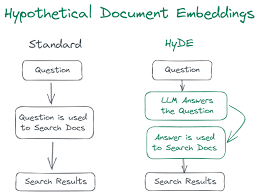

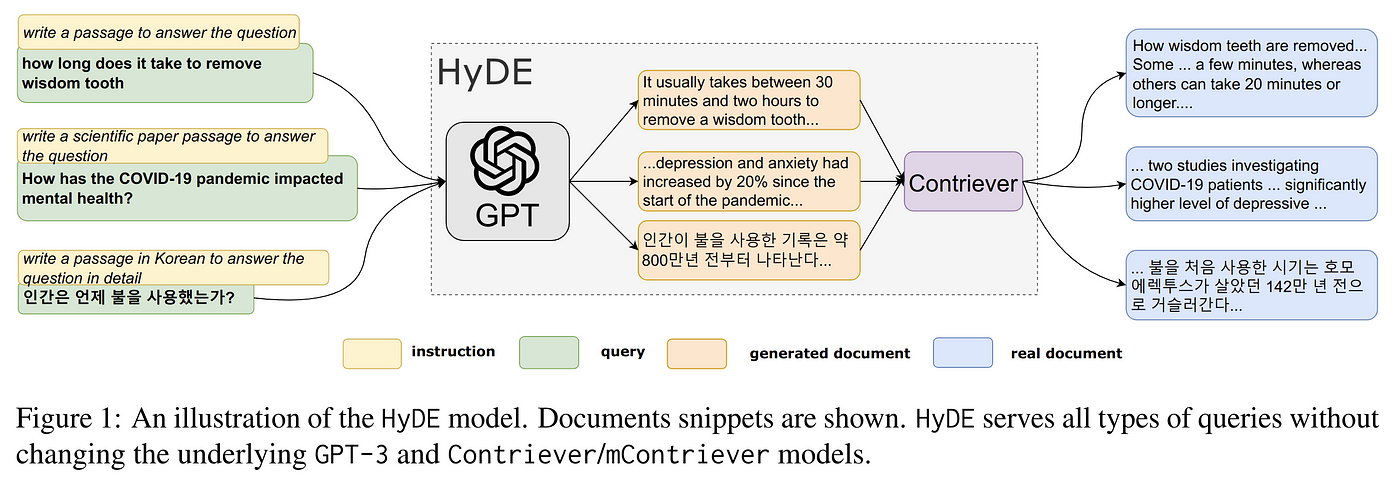

### Shared setup - index `small.pdf` once
Every technique below reuses this one `retriever`. Pipeline: load the PDF -> split into ~500-char child chunks -> embed with `bge-base-en-v1.5` -> add to an in-memory Chroma collection.

In [ ]:
# --- small.pdf : VIT FFCS academic regulations write-up ---
# Colab : upload small.pdf via the Files panel      -> "/content/small.pdf"
# Kaggle: Add Input -> your dataset                 -> "/kaggle/input/<dataset-slug>/small.pdf"
PDF_PATH = "/content/small.pdf"

import os
assert os.path.exists(PDF_PATH), f"PDF not found at {PDF_PATH!r} - upload small.pdf and fix PDF_PATH"

loader = PyPDFLoader(PDF_PATH)

`loader.load()` returns one `Document` per page (`page_content` + `metadata`).

In [5]:
docs = loader.load()

In [6]:
len(docs)

22

`RecursiveCharacterTextSplitter` splits on paragraph -> sentence -> word boundaries, so chunks stay readable. `chunk_overlap=80` repeats a little text across each boundary so a fact split between two chunks still appears whole in one of them.

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,     # small.pdf is only ~3 pages
    chunk_overlap=80,
)


Create the embedding model and an **empty** in-memory Chroma collection, then take a `retriever` handle (defaults to top-4 similarity search).

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")

# in-memory Chroma over the child chunks (no PersistentClient -> no /content path issues)
vector_store_from_client = Chroma(
    collection_name="my_collection",
    embedding_function=embeddings,
)

retriever = vector_store_from_client.as_retriever()

In [9]:
chunks = text_splitter.split_documents(docs)

In [10]:
len(chunks)

73

`add_documents` embeds every chunk and stores the vectors. The retriever is now ready.

In [11]:
retriever.add_documents(chunks)

['fd66b024-ce22-4278-81ff-aca29b0b6ee6',
 '622834ab-9140-49c0-a30c-1deb025275f6',
 '58e3a574-754a-4532-a3ea-a2a79f37bfd5',
 '213c1780-2bc9-43e3-9977-a4966e3565eb',
 '33f521e6-50e2-4874-80b4-43759359c825',
 'ddc75d1b-b5de-4d98-8eca-2fbb5738662d',
 'be818d5d-1470-42c3-ae05-1120a19c05e2',
 'ea28471a-2303-4755-9252-44e01d902643',
 '4d75eb3a-6a84-4132-a822-e5408ea8002e',
 '68f64eb8-68f8-4236-b941-9748ac0b869e',
 'd99ab49c-46e3-41cd-b336-52254eecc380',
 'af3f715b-0d2c-483c-baf9-f2e137557b5f',
 'eb0a42c3-f48b-406d-a5b5-7f80eb4323cd',
 'cde6032d-8785-4013-9a7e-b3b22b1cc187',
 '437c60b4-1208-48ea-8140-1a935fc04648',
 '847e53ef-dfe1-43fb-be2b-ba9ef03d542b',
 'fa323599-7535-4a20-a924-0dc280efb02a',
 '24c92980-a8b1-47ed-b96a-5b69d25611ea',
 '43cf46ad-263c-4221-a364-1064077b1c9f',
 'd12a42c6-52bb-4f3b-b523-ab6e71e3b00a',
 'fa2a6605-9d0f-470f-bbfd-a28bde001d62',
 '5cf030be-d822-45ca-856a-3439d9ac5c83',
 'f820db18-46e6-4585-89c6-c5cd88a8b1be',
 '236c4642-8842-4afc-ba6f-3700fcad4adb',
 '09e1c58a-4017-

### The answer prompt
Shared 'given a question + context, answer as Geeno' template. `{query}` and `{context}` are filled in by the chain at run time.

In [12]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions about VIT University's FFCS academic regulations document.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    Here are some relevant that might be useful for you in
    aswering the question
    {context}"""),
])

#### HyDE step 1 - the hypothetical-answer prompt
Question in, a free-form answer out. Note there is **no** `{context}` slot: the LLM answers from its own parametric knowledge.

In [13]:
hyde_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions about VIT University's FFCS academic regulations document.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    """),
])

#### HyDE step 2 - retrieve using the hypothetical answer
`hyde_retrieve` reads `state['hypothetical_answer']`, runs the vector search with that text (not the original question), and returns the retrieved chunks joined into one string.

In [14]:
def hyde_retrieve(state):
  query = state["hypothetical_answer"]
  results = retriever.invoke(query)
  return " ".join([doc.page_content for doc in results])

#### The LCEL pieces
`RunnableAssign` adds a key to the dict flowing through the chain; `RunnableLambda` wraps a plain Python function as a Runnable; `StrOutputParser` turns the chat message into a plain string.

In [15]:
from langchain_core.runnables import RunnableAssign, RunnableLambda
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

In [16]:
chat_model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

#### Assemble the HyDE chain
`{query}` -> assign `hypothetical_answer` (`hyde_prompt | LLM`) -> assign `context` (`hyde_retrieve` on that answer) -> final `prompt | LLM` -> string.

In [17]:
hyde_chain = (
    RunnableAssign({"hypothetical_answer":hyde_prompt|chat_model|StrOutputParser()})|
    RunnableAssign({"context":RunnableLambda(hyde_retrieve)}) |
    prompt |
    chat_model |
    StrOutputParser()
)

In [19]:
hyde_chain.invoke({"query":"What is FFCS at VIT and when did the university introduce it?"})


'Hello! I am Geeno, your assistant for answering questions about research papers. \n\nBased on the provided text, **DeepSeek-R1** is an advanced AI model developed to address the shortcomings of its predecessor, DeepSeek-R1-Zero (which struggled with poor readability and language mixing). \n\nIn short, DeepSeek-R1 is trained using **Reinforcement Learning (RL) combined with human-friendly cold-start data**. This design allows the model to produce clear, coherent Chains of Thought (CoT), improve overall reasoning performance, and maintain strong general capabilities for tasks like creative writing, summarization, and long-context understanding.'

#### Same chain, but keep every intermediate value
Instead of collapsing to the answer string, assign `answer` as one more key, so you can inspect `hypothetical_answer`, `context` and `answer` side by side.

In [20]:
hyde_chain_with_states = (
    RunnableAssign({"hypothetical_answer":hyde_prompt|chat_model|StrOutputParser()})|
    RunnableAssign({"context": RunnableLambda(hyde_retrieve)}) |
    RunnableAssign({"answer": prompt | chat_model | StrOutputParser()})
)

In [21]:
hyde_chain_with_states.invoke({"query":"What is FFCS at VIT and when did the university introduce it?"})


{'query': 'What is Deep seek R1? explain in short',
 'hypothetical_answer': "Hello! I'm Geeno, your research paper assistant. \n\n**DeepSeek-R1** is an open-weights reasoning model released by the AI company DeepSeek in January 2025. \n\nIn short, it is designed to rival top-tier models like OpenAI's o1 by excelling at complex tasks in mathematics, coding, and logical reasoning. Its key innovation is that it was trained primarily using **large-scale reinforcement learning (RL)** rather than relying heavily on traditional supervised fine-tuning, allowing the model to develop advanced problem-solving behaviors (like self-correction and multi-step reasoning) on its own—all while being produced at a fraction of the cost of competing models.",
 'context': 'Drawback of DeepSeek-R1-Zero Although DeepSeek-R1-Zero exhibits strong reasoning\ncapabilities and autonomously develops unexpected and powerful reasoning behaviors, it faces\nseveral issues. For instance, DeepSeek-R1-Zero struggles with 

## Step-Back Prompting

**Insight:** very specific questions ("How is a student admitted to the B.Tech *Fashion Technology* programme?")
often retrieve poorly, because the document usually states the general rule rather than the narrow case.

**Step-back:** ask the LLM for one *more general* question ("What are the admission routes for B.Tech
programmes at VIT?"), retrieve for **both** the original and the step-back question, and answer from the
combined context. The broader question pulls in the background paragraph the narrow one missed.

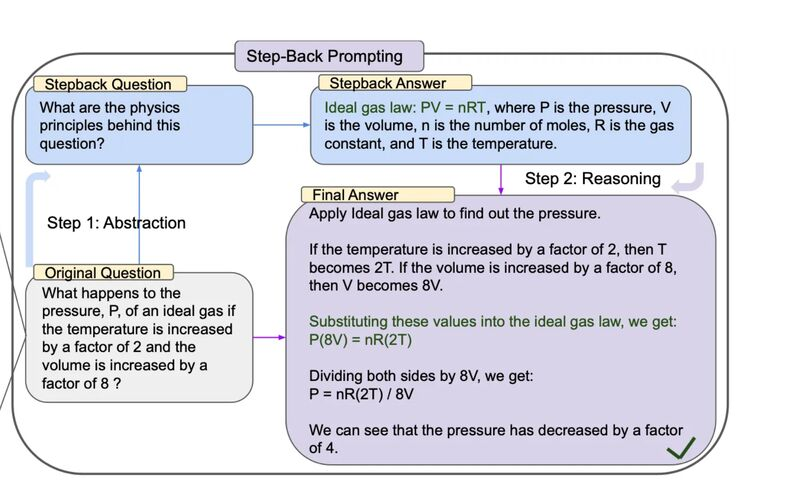

#### The step-back prompt
Asks for the more general question *and* a short answer to it, in a single LLM call.

In [22]:
stepback_prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant."""),
    ("human", """
    Given a specific user question, step back and write ONE more general
    question whose answer would help answer the specific one, then answer
    that general question briefly.
    Here is the user question:
    {query}
    Your reply should contain only the step-back question and its short answer.
    """),
])

#### Chain: specific question -> step-back question + its answer (as a string)

In [23]:
stepback_prompting_chain = stepback_prompt | chat_model | StrOutputParser()

In [24]:
stepback_prompting_chain.invoke(
    {"query": "How is a student admitted to the B.Tech Fashion Technology programme at VIT?"}
)

'**Step-back Question:** \nWhat is the fundamental relationship between pressure, temperature, and volume for an ideal gas?\n\n**Answer:** \nThe relationship is defined by the Ideal Gas Law equation, $PV = nRT$ (where $P$ is pressure, $V$ is volume, $n$ is the amount of gas, $R$ is the ideal gas constant, and $T$ is temperature). Rearranging the formula to solve for pressure gives $P = \\frac{nRT}{V}$, which shows that pressure is directly proportional to temperature and inversely proportional to volume.'

#### Final prompt - original question + step-back background + retrieved context

In [25]:
prompt1 = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated to answer questions
     about VIT University's FFCS academic regulations document.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question using only the context provided.
    Question:
    {query}

    A step-back question and its answer (for extra background):
    {stepback}

    Retrieved context from the document:
    {context}"""),
])

#### Retrieve with both questions, then assemble the chain
`stepback_retrieve` searches with the original query **and** the step-back text, de-duplicates by page content, and joins the result. `final_chain`: assign `stepback` -> assign `context` -> `prompt1 | LLM` -> string.

In [26]:
def stepback_retrieve(state):
  # search with the original question AND the generated step-back question
  docs = retriever.invoke(state["query"]) + retriever.invoke(state["stepback"])
  seen, unique = set(), []
  for d in docs:
    if d.page_content not in seen:
      seen.add(d.page_content)
      unique.append(d)
  return " ".join(d.page_content for d in unique)

final_chain = (
    RunnableAssign({"stepback": stepback_prompting_chain}) |
    RunnableAssign({"context": RunnableLambda(stepback_retrieve)}) |
    prompt1 |
    chat_model |
    StrOutputParser()
)

In [27]:
final_chain.invoke(
    {"query": "How is a student admitted to the B.Tech Fashion Technology programme at VIT?"}
)

"Hello! I am Geeno, your helpful assistant. Let's solve this step-by-step using the Ideal Gas Law mentioned in the step-back question:\n\n1. **Start with the Ideal Gas Law solved for pressure:**\n   $$P_1 = \\frac{nRT_1}{V_1}$$\n\n2. **Apply the changes:**\n   - The temperature $T$ is increased by a factor of 2, so the new temperature $T_2 = 2T_1$.\n   - The volume $V$ is increased by a factor of 8, so the new volume $V_2 = 8V_1$.\n   - The amount of gas ($n$) and the gas constant ($R$) remain constant.\n\n3. **Set up the equation for the new pressure ($P_2$):**\n   $$P_2 = \\frac{nR(2T_1)}{8V_1}$$\n\n4. **Simplify the equation:**\n   $$P_2 = \\left(\\frac{2}{8}\\right) \\frac{nRT_1}{V_1}$$\n   $$P_2 = \\frac{1}{4} \\left(\\frac{nRT_1}{V_1}\\right)$$\n   $$P_2 = \\frac{1}{4} P_1$$\n\n**Answer:**\nWhen the temperature is increased by a factor of 2 and the volume is increased by a factor of 8, the new pressure $P$ decreases to **$\\frac{1}{4}$ of its original value** (or is divided by 4)

## Post-Retrieval Strategies

Pre-retrieval fixed the query. Post-retrieval fixes the **result set**: the vector search returns `k` chunks
ranked only by embedding cosine similarity - fast, but coarse. Post-retrieval steps re-score, re-order,
filter, or compress those chunks *before* they reach the generation prompt.

### Reranking with a Cross-Encoder

- The **bi-encoder** used for retrieval embeds the query and each chunk *separately*, then compares the
  vectors. Fast (chunk vectors are pre-computed), but it never sees query and chunk together.
- A **cross-encoder** feeds `(query, chunk)` as a single input to a transformer and outputs one relevance
  score. Much more accurate, but far too slow to run over the whole corpus.

**Two-stage retrieval:** the bi-encoder fetches a cheap candidate set, the cross-encoder re-scores just
those candidates and keeps the best `top_n`. Model here: `BAAI/bge-reranker-base` (~1.1 GB; GPU recommended).

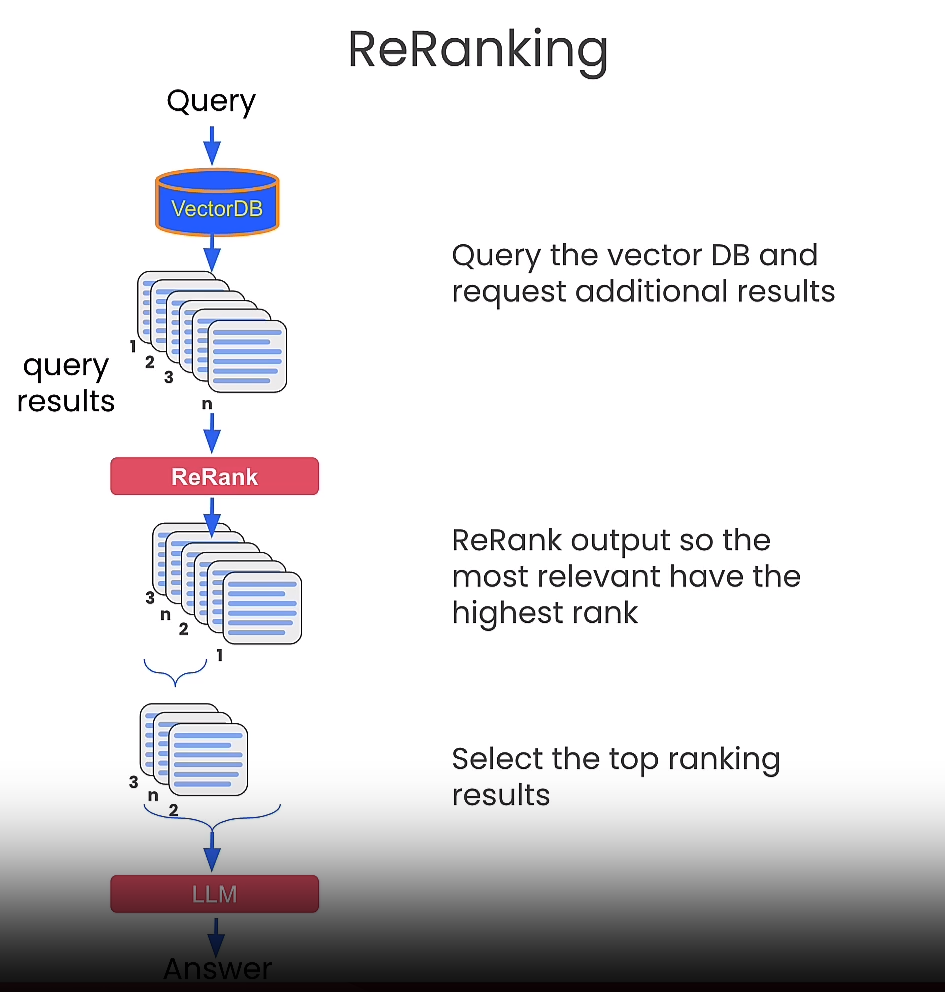

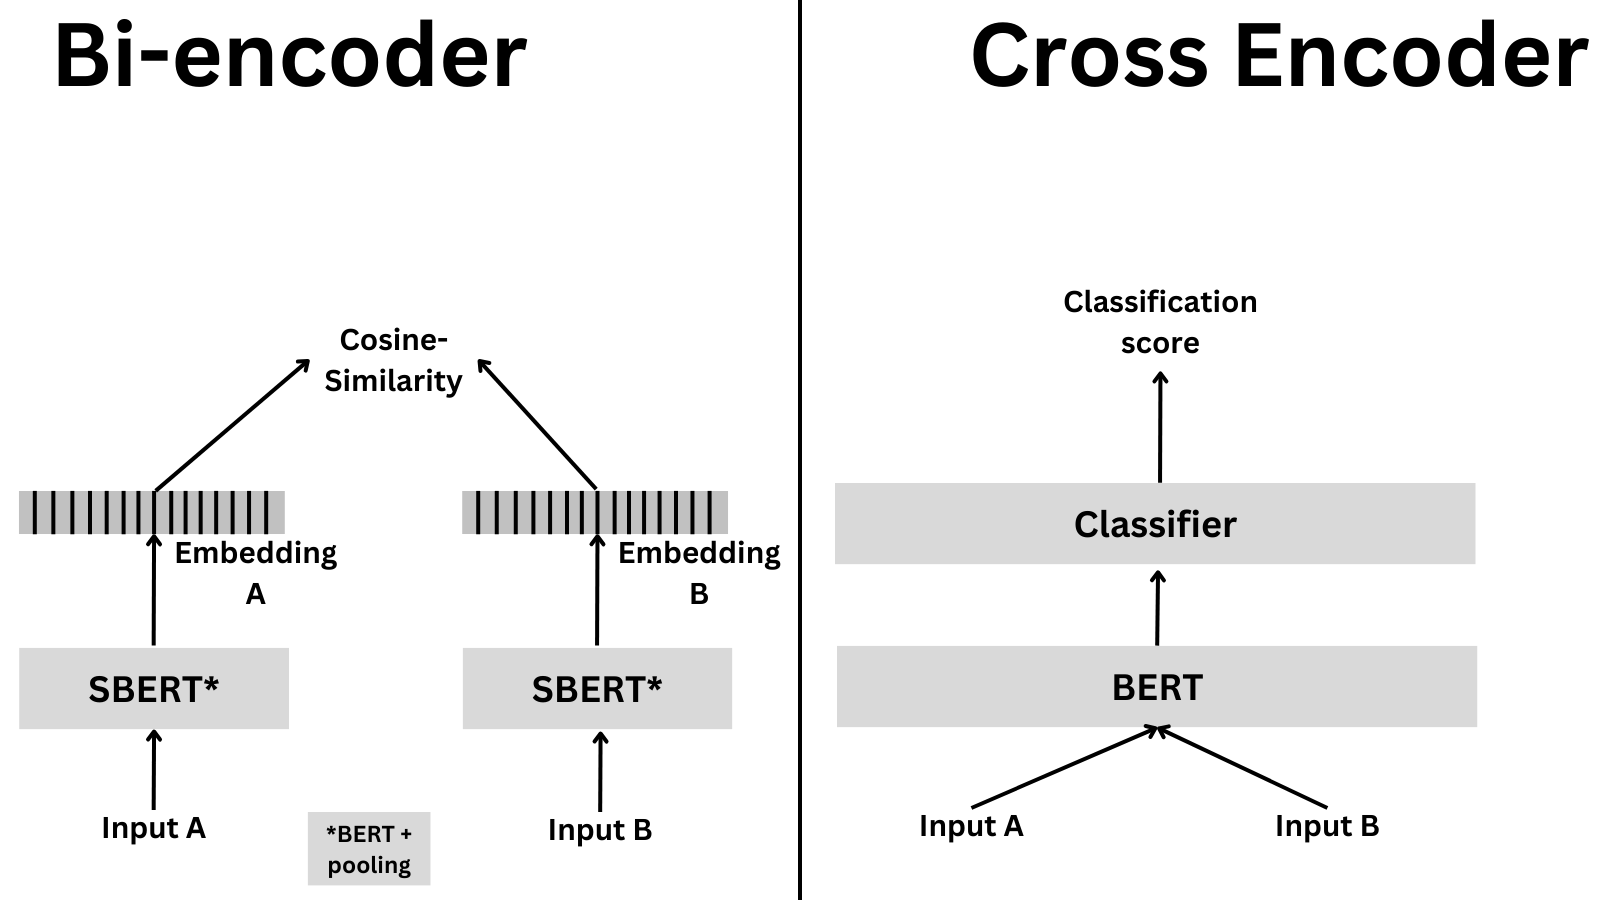

**Run With Caution You will need a GPU to run it!**

#### Load the cross-encoder, define retrieve-then-rerank
`retrieve_and_rerank`: vector search for candidates -> cross-encoder scores every `(query, chunk)` pair -> sort by score -> keep `top_n=3` -> join.

In [30]:
from sentence_transformers import CrossEncoder

# cross-encoder scores (query, passage) pairs directly
reranker = CrossEncoder("BAAI/bge-reranker-base")   # ~1.1 GB; GPU strongly recommended

def retrieve_and_rerank(state, top_n=3):
    query = state["query"]
    docs = retriever.invoke(query)                       # first-stage candidates from FAISS/Chroma
    pairs = [(query, d.page_content) for d in docs]
    scores = reranker.predict(pairs)                     # relevance score per candidate
    ranked = sorted(zip(docs, scores), key=lambda ds: ds[1], reverse=True)
    top_docs = [d for d, _ in ranked[:top_n]]
    return " ".join(d.page_content for d in top_docs)


config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

#### The reranking chain
Same answer `prompt` as before, but `context` now comes from the reranked top-3 instead of the raw similarity search.

In [31]:
reranking_chain = (RunnableAssign({"context":RunnableLambda(retrieve_and_rerank)}) |
         prompt |
         chat_model |
         StrOutputParser()
)

In [33]:
reranking_chain.invoke({"query":"What are the main features of FFCS at VIT?"})


"Hello! I'm Geeno, your research assistant. \n\nBased on the provided text, **DeepSeek-R1** is an advanced AI model that achieves outstanding results on knowledge and reasoning benchmarks (such as MMLU, MMLU-Pro, and GPQA Diamond), outperforming DeepSeek-V3 and surpassing many other closed-source models in educational and factual tasks. \n\nKey highlights of DeepSeek-R1 include:\n* **Strengths:** It performs exceptionally well in engineering-related tasks and handles fact-based queries effectively.\n* **Current Limitations:** It is optimized primarily for Chinese and English (which can cause language mixing issues in other languages), is sensitive to prompts (where few-shot prompting can degrade performance), and currently falls short of DeepSeek-V3 in tasks like function calling, multi-turn interactions, complex role-playing, and JSON output."

## Hybrid Strategies

Instead of improving a *single* retrieval, run **several** retrievals and merge their results. More
independent searches -> more chances the right chunk surfaces in at least one of them, and the merge step
rewards chunks that several searches agree on.

### RAG-Fusion (multi-query + Reciprocal Rank Fusion)

1. **Generate queries:** ask the LLM for ~4 alternative phrasings of the question.
2. **Retrieve per query:** run the vector search for each, producing several ranked lists.
3. **Reciprocal Rank Fusion (RRF):** score every document by `sum of 1/(k + rank)` across the lists
   (`k = 60` by convention). A doc ranked highly in several lists beats a doc ranked #1 in only one.
4. **Generate:** answer from the fused top chunks.

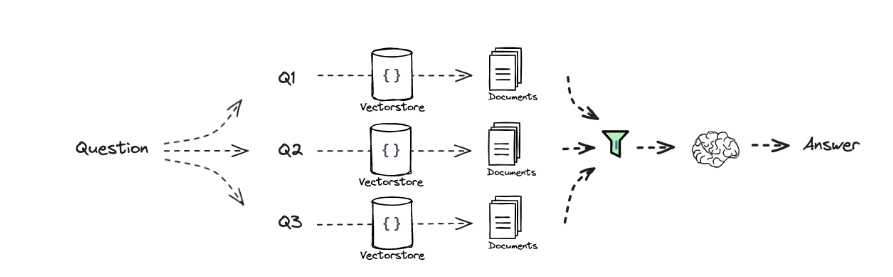

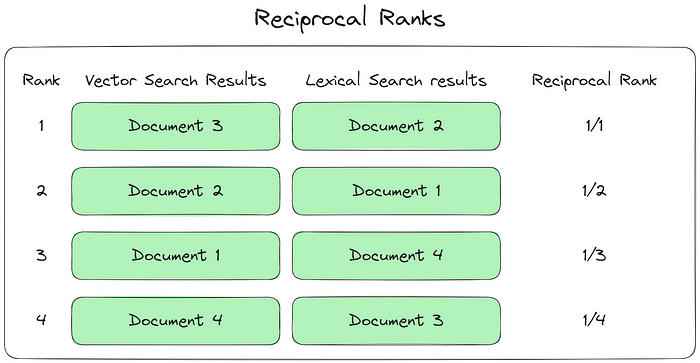

#### Step 1 - the multi-query prompt
One question in, four alternative search queries out (newline-separated).

In [34]:
prompt1 = ChatPromptTemplate.from_messages([
     ("system","""You are a helpful assistant that generates multiple search queries
     about VIT University's FFCS academic regulations, based on a single input."""),
     ("user", "Generate multiple search queries related to: {question}"),
     ("user", "Generate only questions and nothing else. OUTPUT (4 queries sperated by \n):")
 ])

#### Helpers - turn the LLM's text block into a clean list of questions
`check_empty` drops blank lines; `split_questions` splits on newlines and filters.

In [35]:
def check_empty(string):
    if string == " " or not string:
        return False
    else:
        return True

def split_questions(questions):
    q = questions.split("\n")
    return list(filter(check_empty,q))

#### Chain: question -> list of ~4 sub-queries

In [36]:
generate_queries = (
    prompt1 | chat_model | StrOutputParser() | RunnableLambda(split_questions)
)

In [37]:
generate_queries.invoke({"question":"What is FFCS and what are its key features?"})


['What is DeepSeek R1?',
 'How does DeepSeek R1 work?',
 'What are the main features of DeepSeek R1?',
 'Why is DeepSeek R1 important in AI?']

#### Step 3 - Reciprocal Rank Fusion
`langchain_core.load.dumps/loads` serialise a `Document` so it can be used as a dict key. `retriever.map()` runs the retriever once per sub-query (a list of ranked lists); `reciprocal_rank_fusion` merges them with the `1/(k + rank)` formula and returns the fused chunk text.

In [44]:
from langchain_core.load import dumps, loads


In [45]:


def reciprocal_rank_fusion(results: list[list], k=60):
    fused_scores = {}
    for docs in results:
        for rank, doc in enumerate(docs):
            doc_str = dumps(doc)
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            previous_score = fused_scores[doc_str]
            fused_scores[doc_str] += 1 / (rank + k)

    reranked_results = [
        (loads(doc), score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]
    return " ".join([doc.page_content for doc, score in reranked_results])

#### The fusion retrieval chain
`generate_queries` -> retrieve for each sub-query -> RRF merge into one context string.

In [46]:
fusion_chain = generate_queries | retriever.map() | reciprocal_rank_fusion

In [47]:
fusion_chain.invoke({"question":"""What is FFCS and what are its key features?"""})


/tmp/ipykernel_254/4141592808.py:12: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  (loads(doc), score)
/tmp/ipykernel_254/4141592808.py:12: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


'the competition. For engineering-related tasks, DeepSeek-R1 performs slightly better than\nDeepSeek-V3, which could help developers in real world tasks.\n• Knowledge: On benchmarks such as MMLU, MMLU-Pro, and GPQA Diamond, DeepSeek-\nR1 achieves outstanding results, significantly outperforming DeepSeek-V3 with scores\nof 90.8% on MMLU, 84.0% on MMLU-Pro, and 71.5% on GPQA Diamond. While its\nperformance is slightly below that of OpenAI-o1-1217 on these benchmarks, DeepSeek-R1\nsurpasses other closed-source models, demonstrating its competitive edge in educational\ntasks. On the factual benchmark SimpleQA, DeepSeek-R1 outperforms DeepSeek-V3,\ndemonstrating its capability in handling fact-based queries. A similar trend is observed\nwhere OpenAI-o1 surpasses 4o on this benchmark.\n4 general capabilities? To address these questions, we design a pipeline to train DeepSeek-R1. The\npipeline consists of four stages, outlined as follows.\n2.3.1. Cold Start\nUnlike DeepSeek-R1-Zero, to preven

#### Final generation - answer from the fused context
`RunnableParallel` builds `{context: fusion_chain, question: passthrough}`, then `gen_prompt | LLM | parser` produces the grounded answer.

In [48]:
gen_template = """
            You are a helpful, respectful and honest assistant designated answer questions.
            Answer the question based only on the following context.
            Context :{context}
            Question: {question}
           """
gen_prompt = ChatPromptTemplate.from_template(gen_template)

In [49]:
from langchain_core.runnables import RunnableParallel, RunnablePassthrough

In [51]:
setup_retrieve = RunnableParallel(
    {
        "context":fusion_chain,
        "question":RunnablePassthrough()
    }
)

In [52]:
RAG_fusion_chain = setup_retrieve|gen_prompt|chat_model|StrOutputParser()

In [53]:
RAG_fusion_chain.invoke({"question":"What is FFCS and what are its key features?"})


/tmp/ipykernel_254/4141592808.py:12: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


'Based on the provided context, DeepSeek-R1 is an AI model designed and trained through a pipeline consisting of four stages (starting with a cold-start phase using fine-tuned long CoT data). Key highlights of DeepSeek-R1 include:\n\n* **Performance:** It achieves outstanding results on benchmarks like MMLU (90.8%), MMLU-Pro (84.0%), and GPQA Diamond (71.5%), outperforming DeepSeek-V3 and other closed-source models (though slightly below OpenAI-o1-1217 on these benchmarks). \n* **Tasks:** It performs well in educational and fact-based queries (outperforming DeepSeek-V3 on SimpleQA) and slightly better than DeepSeek-V3 on engineering-related tasks.\n* **Limitations:** It is currently optimized for Chinese and English, sensitive to prompts (where few-shot prompting degrades performance), and falls short of DeepSeek-V3 in areas like function calling, multi-turn interactions, complex role-playing, and JSON output.'